# Trabalho Final - notebook base do projeto da Alana

In [1]:
# Bibliotecas usadas na análise: pandas para manipular os dados,
# matplotlib e seaborn para os gráficos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **O uso excessivo de redes sociais está relacionado a piores indicadores de saúde mental entre jovens?**

(tempo diário de uso de redes sociais, indicadores de saúde mental)

--- O uso de redes sociais faz parte da rotina da maior parte dos jovens hoje em dia, e é comum a discussão sobre o impacto desse uso na saúde mental. Neste trabalho será utilizado o conjunto de dados *Social Media and Mental Health*, um levantamento real feito com estudantes e ex-alunos de um curso universitário (formulário aplicado a 481 pessoas, com idade entre 13 e 91 anos, mediana de 22 anos — ou seja, a amostra é majoritariamente jovem, mas não se restringe a adolescentes). Pretende-se avaliar como o tempo diário declarado de uso de redes sociais se relaciona com indicadores de saúde mental autorreferidos (sintomas de depressão, preocupação/ansiedade, problemas de sono, inquietação e dificuldade de concentração), para responder se um uso mais intenso está associado a indicadores piores.

In [2]:
# Carrega o dataset a partir do zip (contém um único CSV, smmh.csv) e mostra as primeiras linhas
df = pd.read_csv("../datasets/alana/social-media-and-mental-health.zip", compression='zip')

df.head()

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


In [3]:
# As colunas do CSV vêm com o texto inteiro da pergunta do formulário, o que é
# inviável de usar no código. Aqui só listamos as colunas originais antes de renomear.
df.columns

Index(['Timestamp', '1. What is your age?', '2. Gender',
       '3. Relationship Status', '4. Occupation Status',
       '5. What type of organizations are you affiliated with?',
       '6. Do you use social media?',
       '7. What social media platforms do you commonly use?',
       '8. What is the average time you spend on social media every day?',
       '9. How often do you find yourself using Social media without a specific purpose?',
       '10. How often do you get distracted by Social media when you are busy doing something?',
       '11. Do you feel restless if you haven't used Social media in a while?',
       '12. On a scale of 1 to 5, how easily distracted are you?',
       '13. On a scale of 1 to 5, how much are you bothered by worries?',
       '14. Do you find it difficult to concentrate on things?',
       '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
       '16. Following the previous question, 

**De-para das colunas:** o dataset original tem cada coluna nomeada com o texto completo da
pergunta do formulário (ex.: `"8. What is the average time you spend on social media every day?"`).
Para tornar o código legível, renomeamos as colunas para nomes curtos em português, mantendo o
sentido de cada pergunta. O de-para usado é:

| Coluna original (resumida) | Nome novo |
|---|---|
| 1. What is your age? | `idade` |
| 2. Gender | `genero` |
| 3. Relationship Status | `status_relacionamento` |
| 4. Occupation Status | `ocupacao` |
| 5. What type of organizations are you affiliated with? | `tipo_organizacao` |
| 6. Do you use social media? | `usa_rede_social` |
| 7. What social media platforms do you commonly use? | `plataformas` |
| 8. What is the average time you spend on social media every day? | `tempo_diario_rs` |
| 9. ...using Social media without a specific purpose? | `uso_sem_proposito` |
| 10. ...distracted by Social media when busy? | `distracao_rs` |
| 11. ...restless if you haven't used Social media in a while? | `inquietacao_sem_rs` |
| 12. ...how easily distracted are you? | `facilidade_distracao` |
| 13. ...how much are you bothered by worries? | `preocupacao` |
| 14. ...difficult to concentrate on things? | `dificuldade_concentracao` |
| 15. ...compare yourself to other successful people...? | `comparacao_social` |
| 16. ...how do you feel about these comparisons? | `sentimento_comparacao` |
| 17. ...seek validation from features of social media? | `busca_validacao` |
| 18. ...feel depressed or down? | `depressao` |
| 19. ...interest in daily activities fluctuate? | `flutuacao_interesse` |
| 20. ...face issues regarding sleep? | `problemas_sono` |

A partir daqui, o notebook usa só os nomes curtos.

In [4]:
# Aplica o de-para de colunas descrito acima
df = df.rename(columns={
    "Timestamp": "timestamp",
    "1. What is your age?": "idade",
    "2. Gender": "genero",
    "3. Relationship Status": "status_relacionamento",
    "4. Occupation Status": "ocupacao",
    "5. What type of organizations are you affiliated with?": "tipo_organizacao",
    "6. Do you use social media?": "usa_rede_social",
    "7. What social media platforms do you commonly use?": "plataformas",
    "8. What is the average time you spend on social media every day?": "tempo_diario_rs",
    "9. How often do you find yourself using Social media without a specific purpose?": "uso_sem_proposito",
    "10. How often do you get distracted by Social media when you are busy doing something?": "distracao_rs",
    "11. Do you feel restless if you haven't used Social media in a while?": "inquietacao_sem_rs",
    "12. On a scale of 1 to 5, how easily distracted are you?": "facilidade_distracao",
    "13. On a scale of 1 to 5, how much are you bothered by worries?": "preocupacao",
    "14. Do you find it difficult to concentrate on things?": "dificuldade_concentracao",
    "15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?": "comparacao_social",
    "16. Following the previous question, how do you feel about these comparisons, generally speaking?": "sentimento_comparacao",
    "17. How often do you look to seek validation from features of social media?": "busca_validacao",
    "18. How often do you feel depressed or down?": "depressao",
    "19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?": "flutuacao_interesse",
    "20. On a scale of 1 to 5, how often do you face issues regarding sleep?": "problemas_sono",
})

df.columns

Index(['timestamp', 'idade', 'genero', 'status_relacionamento', 'ocupacao',
       'tipo_organizacao', 'usa_rede_social', 'plataformas', 'tempo_diario_rs',
       'uso_sem_proposito', 'distracao_rs', 'inquietacao_sem_rs',
       'facilidade_distracao', 'preocupacao', 'dificuldade_concentracao',
       'comparacao_social', 'sentimento_comparacao', 'busca_validacao',
       'depressao', 'flutuacao_interesse', 'problemas_sono'],
      dtype='str')

## Classificação das variáveis associadas à pergunta de pesquisa

In [5]:
# Variável principal de uso: tempo diário declarado de uso de redes sociais
df["tempo_diario_rs"].unique()

<StringArray>
['Between 2 and 3 hours',     'More than 5 hours', 'Between 3 and 4 hours',
     'Less than an Hour', 'Between 1 and 2 hours', 'Between 4 and 5 hours']
Length: 6, dtype: str

O tempo diário de uso de redes sociais é uma variável **categórica ordinal** e possui 6
categorias (`Less than an Hour`, `Between 1 and 2 hours`, `Between 2 and 3 hours`,
`Between 3 and 4 hours`, `Between 4 and 5 hours`, `More than 5 hours`).

In [6]:
# A pergunta de pesquisa fala em "indicadores de saúde mental" de forma genérica: no
# formulário original isso corresponde a vários itens de 1 a 5 sobre sintomas específicos.
# Aqui olhamos o item de depressão como exemplo desse grupo de variáveis.
df["depressao"].unique()

array([5, 4, 3, 1, 2])

In [7]:
# Antes de resumir os cinco itens numa média, é preciso confirmar que todos usam a mesma
# escala E a mesma direção — ou seja, que "5" significa "pior" nos cinco, e não "melhor" em
# algum deles (o enunciado do formulário não deixa isso 100% explícito para todos os itens).
#
# Já sabemos pelo describe() de cada item que todos vão de 1 a 5. Para checar a direção,
# olhamos a correlação entre os cinco: se todos medem o mesmo tipo de mal-estar na mesma
# direção, as correlações entre eles devem ser positivas em todos os pares. Se algum item
# estivesse com a escala invertida, ele apareceria com correlação negativa com os demais.
itens_saude = ["depressao", "preocupacao", "problemas_sono", "inquietacao_sem_rs",
               "dificuldade_concentracao"]

print("Correlação entre os cinco itens de saúde mental:")
print(df[itens_saude].corr().round(2))

Correlação entre os cinco itens de saúde mental:
                          depressao  preocupacao  problemas_sono  \
depressao                      1.00         0.59            0.37   
preocupacao                    0.59         1.00            0.33   
problemas_sono                 0.37         0.33            1.00   
inquietacao_sem_rs             0.33         0.35            0.17   
dificuldade_concentracao       0.51         0.55            0.35   

                          inquietacao_sem_rs  dificuldade_concentracao  
depressao                               0.33                      0.51  
preocupacao                             0.35                      0.55  
problemas_sono                          0.17                      0.35  
inquietacao_sem_rs                      1.00                      0.47  
dificuldade_concentracao                0.47                      1.00  


**Sobre "indicadores de saúde mental":** a pergunta de pesquisa não aponta para uma única
coluna, e o dataset também não tem uma coluna pronta chamada "saúde mental". O que existe são cinco
itens de autorrelato, cada um numa escala de 1 a 5 (quanto maior, mais frequente o sintoma):
`depressao` (com que frequência se sente depressivo/para baixo), `preocupacao` (o quanto é incomodado
por preocupações), `problemas_sono` (com que frequência tem problemas de sono),
`inquietacao_sem_rs` (se fica inquieto sem usar redes sociais) e `dificuldade_concentracao`
(dificuldade de concentração). Cada um deles é uma variável **numérica discreta** e varia de 1 a 5
no dataset.

**Substituição de variável:** como a pergunta pede "indicadores de saúde mental" no
plural e sem apontar uma métrica única, construímos um índice resumo — `indice_saude_mental` —
como a média desses cinco itens (depressão, preocupação, problemas de sono, inquietação e
dificuldade de concentração) para cada pessoa. A ligação é direta: todos os cinco itens descrevem,
na própria pergunta do formulário, sintomas ou sinais de mal-estar psicológico, e resumi-los numa
média é uma operação simples (`mean` por linha), sem inventar nada fora do que os dados já
mostram.

Antes de calcular essa média, porém, verificamos na célula anterior se os cinco itens realmente
podem ser somados/mediados: se todos usam a mesma escala (1 a 5, já confirmado) **e** a mesma
direção (5 = pior em todos, não "melhor" em algum deles). A correlação entre os cinco ficou toda
positiva (de 0.17 a 0.59), sem nenhum par negativo — se algum item estivesse com a escala invertida,
ele apareceria correlacionado negativamente com os demais, o que não acontece. Isso confirma que a
média faz sentido: os cinco itens medem, na mesma direção, o mesmo tipo de mal-estar. Quanto maior o
índice, pior o quadro de saúde mental autorreferido. Os cinco itens continuam sendo analisados
individualmente também, além do índice resumo.

In [8]:
# Cria o índice resumo de saúde mental (média dos 5 itens de sintomas, linha a linha)
df["indice_saude_mental"] = df[["depressao", "preocupacao", "problemas_sono",
                                 "inquietacao_sem_rs", "dificuldade_concentracao"]].mean(axis=1)

df["indice_saude_mental"].describe()

count    481.000000
mean       3.170062
std        0.960175
min        1.000000
25%        2.600000
50%        3.200000
75%        3.800000
max        5.000000
Name: indice_saude_mental, dtype: float64

O índice de saúde mental resultante é uma variável **numérica contínua** e varia de 1.0 a
5.0 na amostra (média 3.18), sendo a média simples dos cinco itens descritos acima.

## Verificando a qualidade dos dados

In [9]:
# Verificando se há duplicatas
df.duplicated().sum()

np.int64(0)

In [10]:
# Se houver dados duplicados, verificamos quais são
df[df.duplicated()]

,timestamp,idade,genero,status_relacionamento,ocupacao,tipo_organizacao,usa_rede_social,plataformas,tempo_diario_rs,uso_sem_proposito,...,facilidade_distracao,preocupacao,dificuldade_concentracao,comparacao_social,sentimento_comparacao,busca_validacao,depressao,flutuacao_interesse,problemas_sono,indice_saude_mental


**Conclusão 1:** não há linhas duplicadas no dataset analisado.

In [11]:
# Verificando se há valores faltantes (soma e porcentagem por coluna)
dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({
    "Dados faltantes (soma)": dados_faltantes_soma,
    "Dados faltantes (porcentagem)": dados_faltantes_porc,
})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
timestamp,0,0.000000
idade,0,0.000000
genero,0,0.000000
status_relacionamento,0,0.000000
ocupacao,0,0.000000
tipo_organizacao,30,6.237006
usa_rede_social,0,0.000000
plataformas,0,0.000000
tempo_diario_rs,0,0.000000
uso_sem_proposito,0,0.000000


**Conclusão 2:** há valores faltantes em apenas 1 coluna, `tipo_organizacao`, com 30 dados
faltantes (6.24% da coluna). Essa coluna não é usada na análise (a pergunta de pesquisa não trata do
tipo de organização à qual a pessoa está filiada), então esse dado faltante não afeta as variáveis
que interessam aqui (`tempo_diario_rs` e os itens de saúde mental), que não têm nenhum valor
faltante.

## Limpeza do conjunto de dados

In [12]:
# Se houver duplicatas, remove a linha inteira que estiver duplicada (não há, mas mantemos
# o passo por consistência com a verificação acima)
df = df.drop_duplicates()

df.shape

(481, 22)

In [13]:
# A coluna "usa_rede_social" pergunta diretamente se a pessoa usa redes sociais.
# 3 pessoas responderam "No" mas mesmo assim informaram plataformas e tempo de uso nas
# perguntas seguintes, o que é uma resposta contraditória. Como a pergunta de pesquisa é
# sobre uso de redes sociais, removemos essas 3 linhas por inconsistência.
df["usa_rede_social"].value_counts()

usa_rede_social
Yes    478
No       3
Name: count, dtype: int64

In [14]:
# Remove as respostas contraditórias (disseram não usar redes sociais, mas informaram tempo de uso)
df = df[df["usa_rede_social"] == "Yes"].copy()

df.shape

(478, 22)

**Conclusão 3:** na limpeza do dataset, removi as 3 linhas em que a pessoa respondeu "No" para
"você usa redes sociais?" mas mesmo assim preencheu plataformas e tempo de uso — uma contradição que
não permite classificar essas respostas com confiança dentro da pergunta de pesquisa. Não havia
duplicatas para remover. A única coluna com dados faltantes (`tipo_organizacao`) não é usada na
análise, então não é preciso reconferir dados faltantes depois da limpeza. A amostra final tem 478
respostas.

## Estatística descritiva

Utiliza as variáveis categórica e numéricas identificadas no início do trabalho para calcular
estatísticas descritivas pertinentes à pergunta de pesquisa.

In [15]:
# O tempo diário de uso já vem em 6 categorias, mas comparar 6 grupos deixa alguns
# muito pequenos (ex.: "Less than an Hour" tem só 33 pessoas) e a leitura fica poluída.
# Não existe uma classificação oficial de "uso excessivo de redes sociais" em horas por dia
# (diferente de, por exemplo, passos diários, que tem referências como Tudor-Locke, 2011) —
# então agrupamos as 6 categorias originais em faixas mais largas, testando diferentes
# granularidades para escolher a que mantém os grupos com tamanho razoável:
#
#   - 3 faixas (Baixo <2h / Médio 2-4h / Alto >4h): grupos de 101, 194 e 183 pessoas
#   - 4 faixas (<1h / 1-3h / 3-5h / >5h): grupos de 33, 169, 160 e 116 pessoas
#   - 5 faixas (quase sem agrupar): grupos de 33, 68, 194, 67 e 116 pessoas
#
# Com 4 ou 5 faixas, o grupo "menos de 1 hora" fica com apenas 33 pessoas, o que deixa a
# média desse grupo instável. Por isso optamos por 3 faixas (equivalente a um corte em
# tercis das categorias originais), que mantém todos os grupos com tamanho parecido e ainda
# preserva um rótulo interpretável ("uso baixo/médio/alto").
mapa_faixas = {
    "Less than an Hour": "Baixo (<2h)",
    "Between 1 and 2 hours": "Baixo (<2h)",
    "Between 2 and 3 hours": "Medio (2-4h)",
    "Between 3 and 4 hours": "Medio (2-4h)",
    "Between 4 and 5 hours": "Alto (>4h)",
    "More than 5 hours": "Alto (>4h)",
}

df["faixa_uso_rs"] = pd.Categorical(
    df["tempo_diario_rs"].map(mapa_faixas),
    categories=["Baixo (<2h)", "Medio (2-4h)", "Alto (>4h)"],
    ordered=True,
)

df["faixa_uso_rs"].value_counts().reindex(["Baixo (<2h)", "Medio (2-4h)", "Alto (>4h)"])

faixa_uso_rs
Baixo (<2h)     101
Medio (2-4h)    194
Alto (>4h)      183
Name: count, dtype: int64

In [16]:
# Calcula a média de cada indicador de saúde mental (e do índice resumo) em cada faixa
# de uso de redes sociais, para ver se uso mais alto está associado a indicadores piores
colunas_saude = ["depressao", "preocupacao", "problemas_sono", "inquietacao_sem_rs",
                  "dificuldade_concentracao", "indice_saude_mental"]

df_med_uso = df.groupby("faixa_uso_rs", observed=True)[colunas_saude].mean()

print("Média dos indicadores de saúde mental por faixa de uso de redes sociais:")
print(df_med_uso)

print("\n################################\n")

print("Maior média encontrada em cada indicador:")
print(df_med_uso.max())

print("\nFaixa de uso correspondente à maior média em cada indicador:")
print(df_med_uso.idxmax())

Média dos indicadores de saúde mental por faixa de uso de redes sociais:
              depressao  preocupacao  problemas_sono  inquietacao_sem_rs  \
faixa_uso_rs                                                               
Baixo (<2h)    2.574257     2.861386        2.811881            1.702970   
Medio (2-4h)   3.268041     3.644330        3.195876            2.623711   
Alto (>4h)     3.650273     3.885246        3.453552            3.065574   

              dificuldade_concentracao  indice_saude_mental  
faixa_uso_rs                                                 
Baixo (<2h)                   2.445545             2.479208  
Medio (2-4h)                  3.381443             3.222680  
Alto (>4h)                    3.573770             3.525683  

################################

Maior média encontrada em cada indicador:
depressao                   3.650273
preocupacao                 3.885246
problemas_sono              3.453552
inquietacao_sem_rs          3.065574
dificuldade

**Conclusão 4:** para todos os cinco indicadores de saúde mental e para o índice resumo, a
maior média aparece na faixa de uso **Alto (>4h)**, e a menor sempre na faixa **Baixo (<2h)** — o
padrão é consistente e crescente entre as três faixas (Baixo < Médio < Alto) em todos os casos.
O índice resumo de saúde mental sobe de 2.48 (uso baixo) para 3.22 (uso médio) e 3.53 (uso alto).
O item com maior diferença entre os extremos é `inquietacao_sem_rs` (1.70 no grupo de uso baixo
contra 3.07 no grupo de uso alto, quase o dobro), o que faz sentido: quem já usa pouco redes
sociais tende a sentir menos falta dela.

In [17]:
# O resultado acima é o esperado (mais uso -> indicadores piores), mas antes de afirmar
# associação vale checar se os grupos de uso não diferem também em idade/ocupação, o que
# poderia confundir a leitura (ex.: se um grupo for sistematicamente mais jovem ou composto
# por estudantes, que costumam relatar mais estresse independente do uso de redes sociais)
print("Idade média, mediana, mínima e máxima por faixa de uso de redes sociais:")
print(df.groupby("faixa_uso_rs", observed=True)["idade"].agg(["mean", "median", "min", "max"]))

print("\n################################\n")

print("Composição de ocupação (%) por faixa de uso de redes sociais:")
print((df.groupby("faixa_uso_rs", observed=True)["ocupacao"]
       .value_counts(normalize=True).round(3) * 100))

Idade média, mediana, mínima e máxima por faixa de uso de redes sociais:
                   mean  median   min   max
faixa_uso_rs                               
Baixo (<2h)   32.782178    29.0  14.0  56.0
Medio (2-4h)  25.525773    22.0  14.0  91.0
Alto (>4h)    23.020219    22.0  13.0  69.0

################################

Composição de ocupação (%) por faixa de uso de redes sociais:
faixa_uso_rs  ocupacao          
Baixo (<2h)   Salaried Worker       54.5
              University Student    39.6
              School Student         4.0
              Retired                2.0
Medio (2-4h)  University Student    63.4
              Salaried Worker       24.2
              School Student        10.8
              Retired                1.5
Alto (>4h)    University Student    69.9
              Salaried Worker       15.3
              School Student        13.1
              Retired                1.6
Name: proportion, dtype: float64


**Conclusão 5:** há um confundidor real aqui. O grupo de uso **Baixo (<2h)** é bem mais velho
(idade média 32.8 anos, mediana 29) e majoritariamente composto por trabalhadores assalariados
(54.5% "Salaried Worker"), enquanto o grupo de uso **Alto (>4h)** é mais jovem (idade média 23.0,
mediana 22) e majoritariamente formado por estudantes universitários (69.9% "University Student").
Ou seja, quem usa mais redes sociais nesta amostra tende a ser mais jovem e estudante — dois fatores
que por si só já costumam vir acompanhados de mais relatos de estresse, sono irregular e
preocupação, independentemente do uso de redes sociais. Isso não invalida a associação observada,
mas significa que parte da diferença entre os grupos pode refletir idade/ocupação, e não só o tempo
de uso de redes sociais. Por isso a conclusão final trata o resultado como uma **associação**, não
como uma relação de causa.

**Conclusão final (síntese):** dentro desta amostra de 478 respostas de um levantamento real
com estudantes e ex-alunos de um curso universitário, o uso excessivo de redes sociais **aparece
associado** a indicadores de saúde mental piores entre os jovens respondentes: a média de todos os
cinco indicadores analisados (sintomas de depressão, preocupação, problemas de sono, inquietação
sem redes sociais e dificuldade de concentração), assim como o índice resumo que os combina, cresce
de forma consistente da faixa de uso **Baixo (<2h/dia)** para **Médio (2-4h/dia)** e **Alto
(>4h/dia)** — o índice resumo passa de 2.48 para 3.22 e 3.53, respectivamente. Ainda assim, essa
associação não pode ser lida como causal: o grupo de uso alto é sistematicamente mais jovem e mais
concentrado em estudantes universitários do que o grupo de uso baixo, o que é um confundidor real
já que idade e ocupação por si só influenciam níveis relatados de estresse e sono. A resposta à
pergunta de pesquisa, portanto, é que **sim, há uma associação consistente entre uso mais intenso de
redes sociais e piores indicadores de saúde mental nesta amostra**, mas o desenho observacional do
estudo não permite afirmar que o uso de redes sociais seja a causa dessa diferença.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

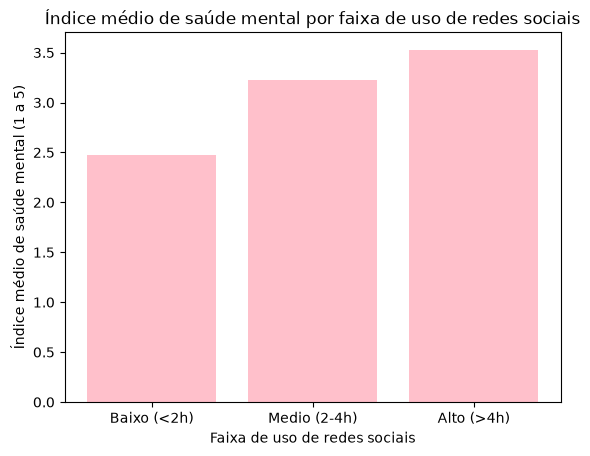

In [18]:
# Gráfico de barras: índice de saúde mental por faixa de uso de redes sociais
plt.bar(df_med_uso.index, df_med_uso["indice_saude_mental"], color="pink")
plt.title("Índice médio de saúde mental por faixa de uso de redes sociais")
plt.xlabel("Faixa de uso de redes sociais")
plt.ylabel("Índice médio de saúde mental (1 a 5)")
plt.show()

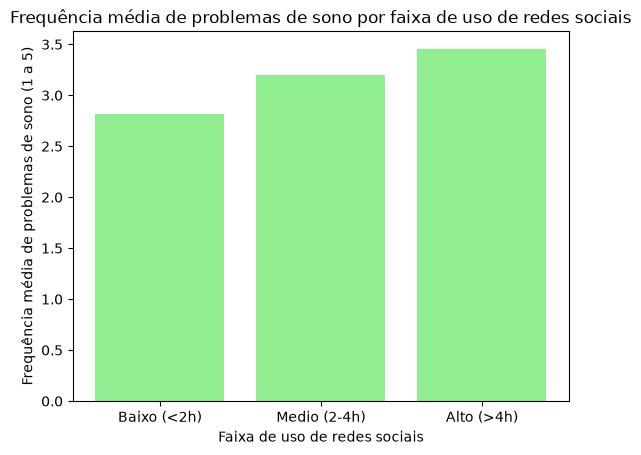

In [19]:
# Gráfico de barras: frequência de problemas de sono por faixa de uso de redes sociais
plt.bar(df_med_uso.index, df_med_uso["problemas_sono"], color="lightgreen")
plt.title("Frequência média de problemas de sono por faixa de uso de redes sociais")
plt.xlabel("Faixa de uso de redes sociais")
plt.ylabel("Frequência média de problemas de sono (1 a 5)")
plt.show()